# SENTINEL Fraud EDA
Exploratory analysis of combined PaySim + Sparkov fraud data.

In [5]:
# 1. Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

data_path = '../data/processed/combined_transactions.csv'
cols = [
    'amount', 'is_fraud', 'transaction_type', 'hour_of_day',
    'day_of_month', 'balance_change_orig', 'balance_ratio',
    'has_balance_info', 'source'
 ]

pdf = pd.read_csv(data_path, usecols=cols)

# Downsample for notebook-speed EDA while keeping class/source distribution representative.
max_rows = 500000
if len(pdf) > max_rows:
    pdf = pdf.sample(n=max_rows, random_state=42)

print('Loaded shape (rows, cols):', pdf.shape)
print(pdf.dtypes)

Loaded shape (rows, cols): (500000, 9)
amount                 float64
is_fraud                 int64
transaction_type        object
hour_of_day              int64
day_of_month             int64
balance_change_orig    float64
balance_ratio          float64
has_balance_info         int64
source                  object
dtype: object


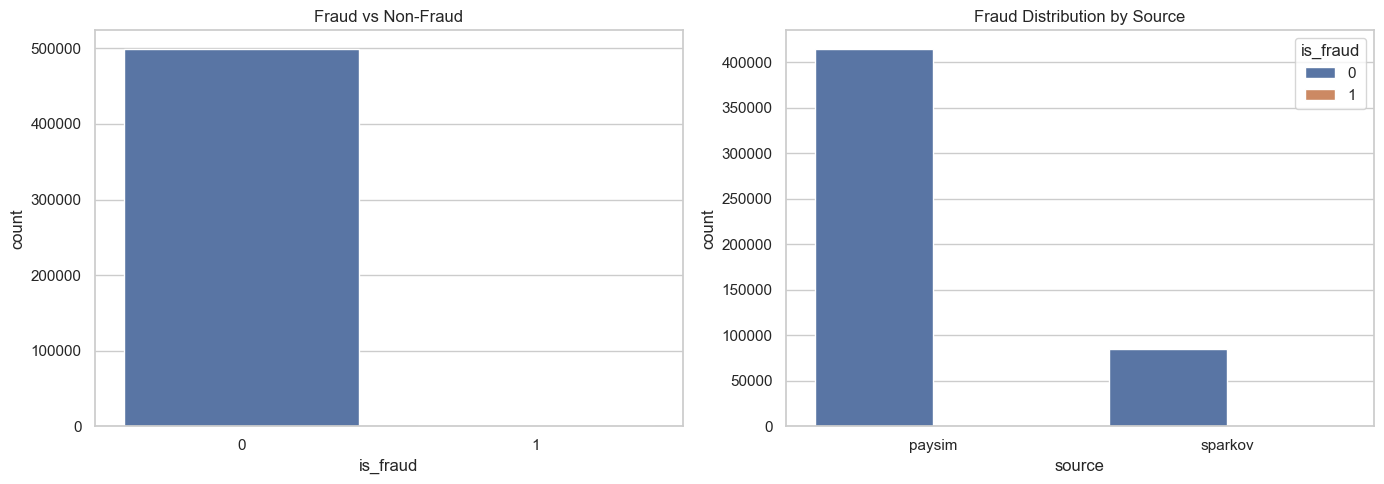

In [8]:
# 2. Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=pdf, x='is_fraud', ax=axes[0])
axes[0].set_title('Fraud vs Non-Fraud')

source_dist = pdf.groupby(['source', 'is_fraud']).size().reset_index(name='count')
sns.barplot(data=source_dist, x='source', y='count', hue='is_fraud', ax=axes[1])
axes[1].set_title('Fraud Distribution by Source')
plt.tight_layout()

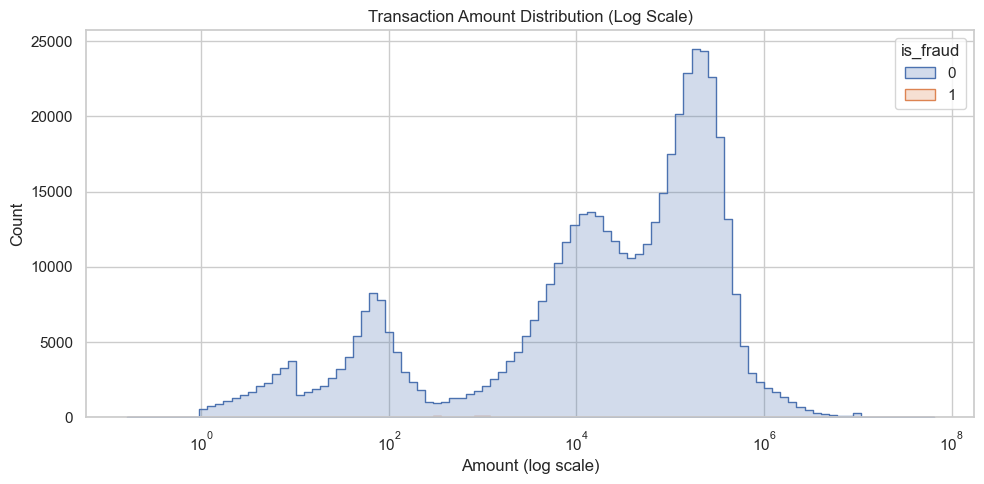

In [14]:
# 3. Amount Analysis
plt.figure(figsize=(10, 5))
sns.histplot(data=pdf, x='amount', hue='is_fraud', bins=100, log_scale=True, element='step')
plt.title('Transaction Amount Distribution (Log Scale)')
plt.xlabel('Amount (log scale)')
plt.ylabel('Count')
plt.tight_layout()

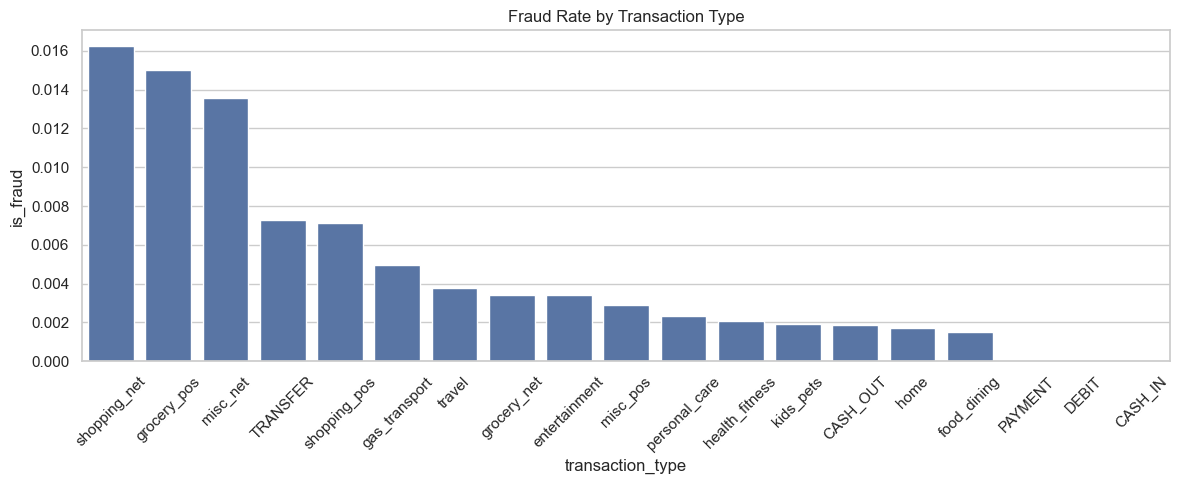

In [15]:
# 4. Transaction Types
tx_fraud = pdf.groupby('transaction_type')['is_fraud'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 5))
sns.barplot(data=tx_fraud, x='transaction_type', y='is_fraud')
plt.title('Fraud Rate by Transaction Type')
plt.xticks(rotation=45)
plt.tight_layout()

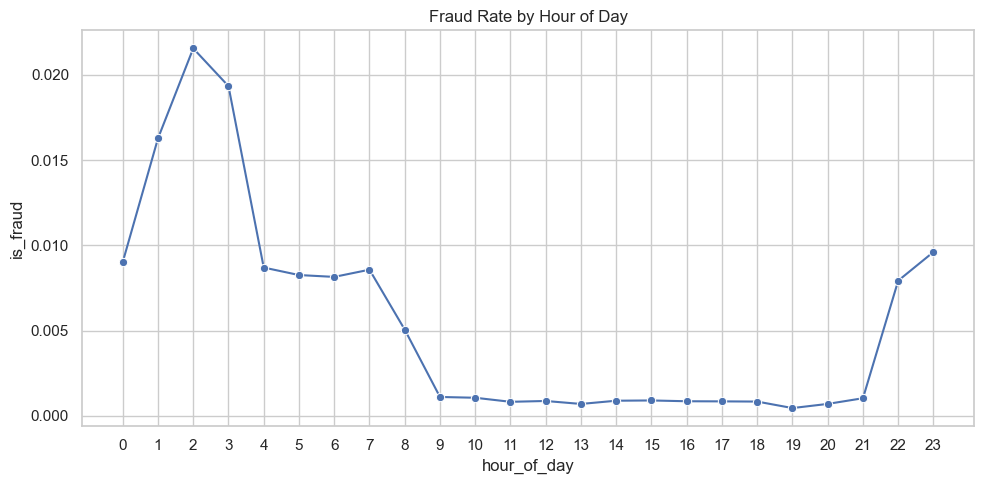

In [16]:
# 5. Temporal Patterns
hour_fraud = pdf.groupby('hour_of_day')['is_fraud'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=hour_fraud, x='hour_of_day', y='is_fraud', marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.xticks(range(0, 24))
plt.tight_layout()

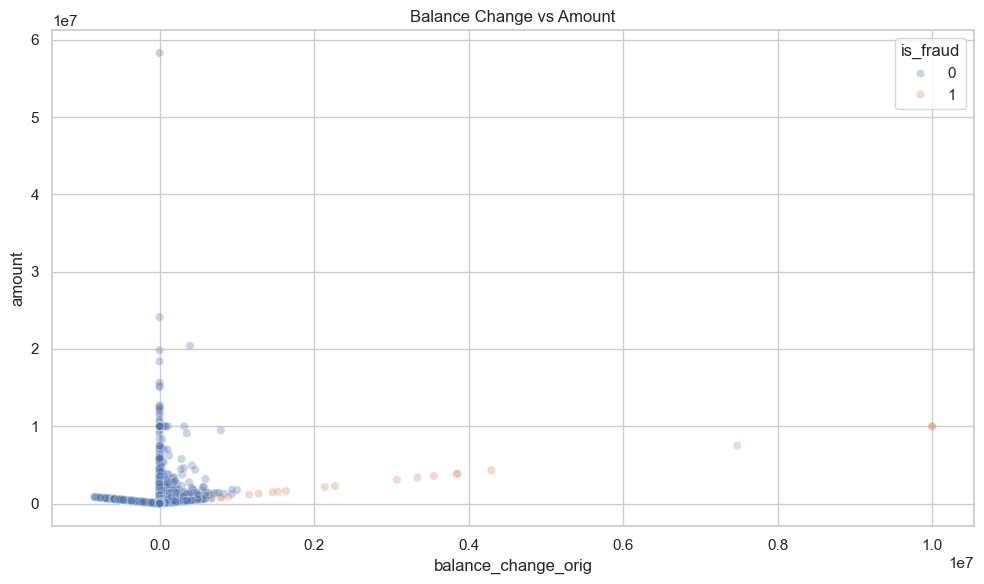

In [17]:
# 6. Balance Features
sample_pdf = pdf.sample(min(len(pdf), 50000), random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_pdf, x='balance_change_orig', y='amount', hue='is_fraud', alpha=0.3)
plt.title('Balance Change vs Amount')
plt.tight_layout()

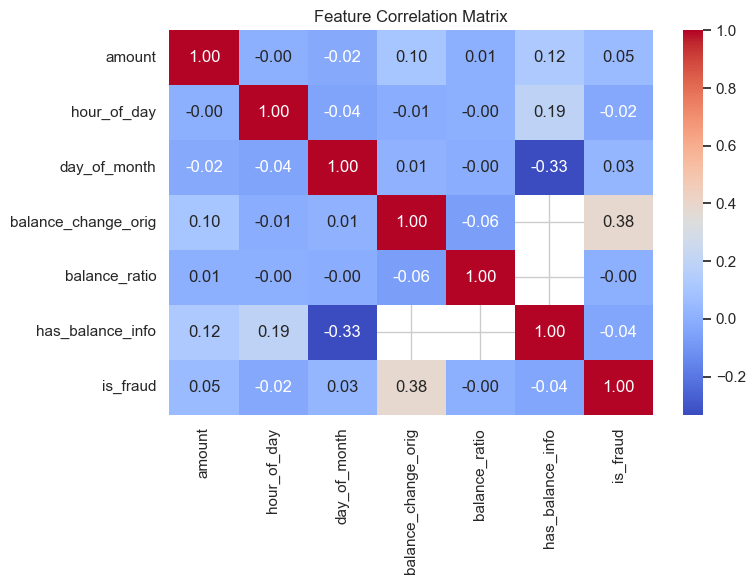

In [18]:
# 7. Correlation Matrix
corr_cols = ['amount', 'hour_of_day', 'day_of_month', 'balance_change_orig', 'balance_ratio', 'has_balance_info', 'is_fraud']
corr_df = pdf[corr_cols].copy()
for c in corr_cols:
    corr_df[c] = pd.to_numeric(corr_df[c], errors='coerce')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()

## 8. Key Findings
- Fraud is typically a minority class with strong imbalance.
- Certain transaction types carry higher fraud rates.
- Temporal fraud behavior can peak at specific hours.
- Balance-derived features add useful separability for fraud detection.
- Source-aware modeling helps when combining heterogeneous datasets (PaySim + Sparkov).

# SENTINEL Fraud EDA
Quick checks on processed features before modeling.

In [19]:
import pandas as pd
from pathlib import Path

features_path = Path('../data/processed/features.csv')
if features_path.exists():
    df = pd.read_csv(features_path)
    display(df.head())
    display(df.describe(include='all'))
else:
    print('Run preprocess stage first to generate data/processed/features.csv')

,amount,is_fraud,hour_of_day,day_of_month,balance_change_orig,balance_ratio,has_balance_info,tx_amount_log,is_high_amount,hour_sin,...,transaction_type_personal_care,transaction_type_shopping_net,transaction_type_shopping_pos,transaction_type_travel,source_paysim,source_sparkov,amount_bin_high,amount_bin_low,amount_bin_medium,amount_bin_very_high
0,75.62,0,4,24,NaN,NaN,0,4.338858,0,0.866025,...,0,0,0,0,0,1,0,1,0,0
1,12615.72,0,11,10,0.00,0.000000,1,9.442778,0,0.258819,...,0,0,0,0,1,0,1,0,0,0
2,103311.88,0,20,9,-103311.88,1.007452,1,11.545517,0,-0.866025,...,0,0,0,0,1,0,0,0,0,1
3,36.16,0,11,22,NaN,NaN,0,3.615233,0,0.258819,...,0,0,0,0,0,1,0,1,0,0
4,169221.36,0,13,8,0.00,0.000000,1,12.038969,0,-0.258819,...,0,0,0,0,1,0,0,0,0,1


,amount,is_fraud,hour_of_day,day_of_month,balance_change_orig,balance_ratio,has_balance_info,tx_amount_log,is_high_amount,hour_sin,...,transaction_type_personal_care,transaction_type_shopping_net,transaction_type_shopping_pos,transaction_type_travel,source_paysim,source_sparkov,amount_bin_high,amount_bin_low,amount_bin_medium,amount_bin_very_high
count,7.659295e+06,7.659295e+06,7.659295e+06,7.659295e+06,6.362620e+06,6.362620e+06,7.659295e+06,7.659295e+06,7.659295e+06,7.659295e+06,...,7.659295e+06,7.659295e+06,7.659295e+06,7.659295e+06,7.659295e+06,7.659295e+06,7.659295e+06,7.659295e+06,7.659295e+06,7.659295e+06
mean,1.494242e+05,2.052278e-03,1.489541e+01,1.053328e+01,-2.123056e+04,3.854081e+02,8.307057e-01,9.603772e+00,2.185018e-01,-3.963057e-01,...,1.184939e-02,1.273525e-02,1.523273e-02,5.288607e-03,8.307057e-01,1.692943e-01,2.923560e-01,1.874043e-01,1.497980e-01,3.704417e-01
std,5.544894e+05,4.525556e-02,4.927048e+00,6.894783e+00,1.466433e+05,9.987283e+03,3.750117e-01,3.244398e+00,4.132297e-01,5.865974e-01,...,1.082081e-01,1.121297e-01,1.224773e-01,7.253026e-02,3.750117e-01,3.750117e-01,4.548450e-01,3.902358e-01,3.568733e-01,4.829230e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.915268e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.369265e+03,0.000000e+00,1.200000e+01,6.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,8.382579e+00,0.000000e+00,-8.660254e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.583751e+04,0.000000e+00,1.500000e+01,1.000000e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.048678e+01,0.000000e+00,-5.000000e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.762270e+05,0.000000e+00,1.900000e+01,1.400000e+01,1.015044e+04,9.765140e-01,1.000000e+00,1.207953e+01,0.000000e+00,1.224647e-16,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
max,9.244552e+07,1.000000e+00,2.300000e+01,3.100000e+01,1.000000e+07,8.131608e+05,1.000000e+00,1.834213e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
